# Part 4: Adaptive Inference for a Precessing Qubit
#### *Tutorial by [Alexandra Ramôa](https://sites.google.com/view/alexandraramoa)*

Now we will use the utility calculations from the previous tutorial to implement Bayesian experimental design. Our strategy will be greedy (locally optimal) variance minimization. The algorithmic workflow is:
1. Choose a measurement time by minimizing the variance for the next experiment.
2. Perform a measurement using this optimized time.
3. Update the Bayesian distribution.
4. Return to 1.
The termination criterion can be the total number of experiments, or a target standard deviation.

Here we simulate the "experiments" using the function `measure(w_true, t)` below.

## Imports and auxiliary functions

Useful imports and definitions from the previous notebook.

In [ ]:
import numpy as np
from scipy.special import logsumexp
from copy import deepcopy
import matplotlib.pyplot as plt

def generate_dataset(w):
  ts = np.linspace(0, 10, 20)
  ps = np.cos(w*ts/2)**2
  ys = np.random.binomial(1, ps)
  return list(zip(ts, ys))

def split_data(data):
    ts = np.array([datum[0] for datum in data])
    ys = np.array([datum[1] for datum in data])
    return ts, ys

def measure(w_true, t):
    p1 = np.cos(w_true * t / 2)**2
    y = np.random.binomial(1, p1)
    return y

## 4.1 Optimizing controls

The following class implementation of Bayesian inference is similar to the previous one, with the addition of the method `expected_utility(self, t)` and its auxiliary methods. These were added directly from the last exercises of the previous notebook.  

**Define a new method `optimize_time(self, tmax, Neval)` that chooses the best time among `Neval` random possibilities picked from the interval $t \in [0,\text{tmax}]$ .**

In [ ]:
class BayesianDistribution():
    def __init__(self, domain, Npoints=100):
        self.ws = np.linspace(domain[0], domain[1], Npoints)
        self.ps = np.zeros(Npoints)

    def mean_and_std(self):
        ws, logps = self.ws, self.ps
        logZ = logsumexp(logps)
        ps = np.exp(logps - logZ)
        mu = np.sum(ps * ws)
        std = np.sqrt(np.sum(ps * (ws - mu)**2))
        return mu, std

    def expectation(self, function, description="", after_function=lambda x: x,
                    silent=True):
        ws, logps = self.ws, self.ps
        logZ = logsumexp(logps)
        ps = np.exp(logps - logZ)
        e = np.sum(ps * function(ws))
        e = after_function(e)
        if not silent:
            print(f"> Calculated expectation, {description} = {e:.2f}.")
        return e

    def Bayes_update(self, data, silent=True):
        self.ps += self.loglikelihoods(data)
        if not silent:
            print(f"> Updated distribution based on {len(data)} data.")

    def loglikelihoods(self, data, eps=1e-10):
        ts, ys = split_data(data)
        args = np.outer(self.ws, ts) / 2.0
        p1s = np.cos(args) ** 2
        p1s = np.clip(p1s, eps, 1 - eps)
        Ls = np.sum(ys*np.log(p1s) + (1 - ys)*np.log1p(-p1s), axis=1)
        return Ls

    def print_info(self):
        mu, std = self.mean_and_std()
        print(f"> Mean and std: {mu:.2f} ± {std:.2f}.")

    def expected_std(self, t):
        ep1 =  self.expected_py(t, 1)
        ep0 =  self.expected_py(t, 0)

        std_0 = self.conditional_std(t, 0)
        std_1 = self.conditional_std(t, 1)

        exp_std = ep1 * std_1 + ep0 * std_0

    def conditional_std(self, t, y):
      cd = deepcopy(self)
      cd.Bayes_update([(t, y)])
      cstd = cd.mean_and_std()[1]
      return cstd

    def likelihood(self, w, t, y):
        if y==1:
            return np.cos(w*t/2)**2
        if y==0:
            return np.sin(w*t/2)**2

    def expected_py(self, t, y):
        py = lambda w: self.likelihood(w, t, y)
        epy = self.expectation(py, description = f"p{y}")
        return epy

    def expected_utility(self, t):
        ep1 =  self.expected_py(t, 1)
        ep0 =  self.expected_py(t, 0)

        std_0 = self.conditional_std(t, 0)
        std_1 = self.conditional_std(t, 1)

        exp_std = ep1 * std_1 + ep0 * std_0
        return exp_std

    # Write your code below.

    ### Solution:
    def optimize_time(self, tmax, Neval):
        best_t = 0
        best_exp_std = np.inf
        ts = np.random.uniform(0, tmax, Neval)

        for t in ts:
            exp_std = self.expected_utility(t)
            if exp_std < best_exp_std:
                best_exp_std = exp_std
                best_t = t

        return best_t

## 4.2 Performing adaptive inference

**Use the method you just defined to perform adaptive inference following the 3-step scheme mentioned in the beginning. Print the mean and standard deviation at each step.**

In [ ]:
# Write your code below.

### Solution:
domain = (0, 10)
w_true = 2.3
tmax = 100
nsteps = 30

d = BayesianDistribution(domain, Npoints=400)
data = []
for k in range(nsteps):
    t = np.random.uniform(0,10) # d.optimize_time(tmax, Neval = 100)
    y = measure(w_true, t)

    datum = (t, y)
    d.Bayes_update([datum])

    mu, std = d.mean_and_std()
    if (k+1) % 5 == 0:
      print(f"> Step {k+1:2d}: {mu:.2f} ± {std:.2f}")

> Step  5: 6.27 ± 2.39
> Step 10: 3.49 ± 2.10
> Step 15: 2.37 ± 0.27
> Step 20: 2.39 ± 0.36
> Step 25: 2.37 ± 0.18
> Step 30: 2.34 ± 0.04


**Define a function `run_inference(w_true, domain, tmax, nsteps, Npoints, Neval, strategy)` that runs inference and returns a list of cumulative times, and a list of standard deviations. Test this function using the 2 cells below to plot the performance.**

For instance, for 3 iterations, if the standard deviations $[2.4, 2.1, 1.9]$ and the measurement times were $[1.2, 5.3, 6.5]$, the function should return the lists $[1.2, 6.5, 13]$ and $[2.4, 2.1, 1.9]$.

The arguments are:
- `w_true`: the true parameter value.
- `domain`: range of values for the $\omega$ parameter.
- `tmax`: maximum time.
- `nsteps`: number of iterations/experiments.
- `Npoints`: number of points used for the discretization (argument to `BayesianDistribution`), default value $500$.
- `Neval`: number of times to be considered when optimizing the time (pick 1 out of Neval), default value $100$.
- `strategy`: "adaptive" or "random". In the first case, use the optimization; in the second, pick the time at random from $[0, \text{tmax}]$. Default "adaptive".

The random strategy serves as a benchmark: we want to check whether our optimization is better than relying on "luck".

In [ ]:
# Write your code below.

### Solution:
def run_inference(w_true, domain, tmax, nsteps, Npoints=500, Neval = 100, strategy="adaptive"):
    d = BayesianDistribution(domain, Npoints=Npoints)
    data = generate_dataset(w_true)
    d.Bayes_update(data)

    ct = 0
    stds = []
    cts = []

    for _ in range(nsteps):
        if strategy == "adaptive":
            t = d.optimize_time(tmax, Neval)
        elif strategy == "random":
            t = np.random.uniform(0, tmax)
        else:
            raise ValueError("strategy must be 'adaptive' or 'random'")

        y = measure(w_true, t)
        d.Bayes_update([(t, y)])

        ct += t
        stds.append(d.mean_and_std()[1])
        cts.append(ct)

    return np.array(stds), np.array(cts)

In [ ]:
def plot_inference(y, x):
    plt.figure(figsize=(7, 5))

    plt.loglog(x, y, marker='o')

    plt.xlabel("Cumulative time")
    plt.ylabel("Posterior standard deviation")
    plt.grid(True, which="both", ls=":")
    plt.show()

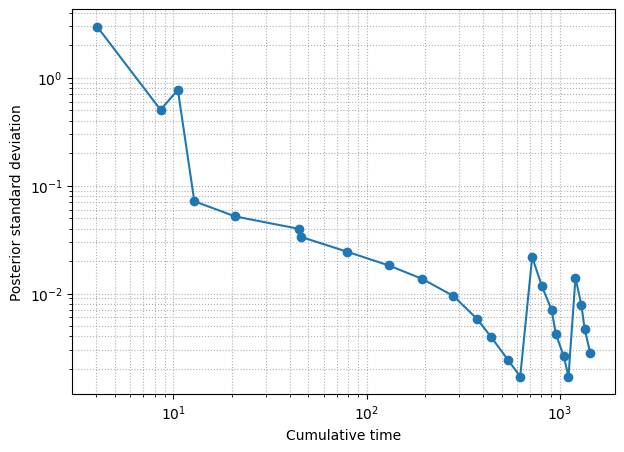

In [ ]:
domain = (0, 10)
w_true = 2.3
tmax = 100
nsteps = 25

r = run_inference(w_true, domain, tmax, nsteps)
plot_inference(*r)

## 4.3 Averaging over runs

The results are stochastic, so we want to look at statistical averages such as the mean. The following functions do exactly this: repeatedly run inference and average over runs, to better assess the performance of the random and adaptive methods.

Run the cells and and observe the results.

In [ ]:
def average_runs(w_true, domain, tmax, nsteps, nruns=50, Npoints=200, strategy="adaptive"):
    all_stds = []
    all_cts = []

    for _ in range(nruns):
        stds, cts = run_inference(
            w_true=w_true,
            domain=domain,
            tmax=tmax,
            nsteps=nsteps,
            Npoints=Npoints,
            strategy=strategy
        )
        all_stds.append(stds)
        all_cts.append(cts)

    mean_stds = np.mean(all_stds, axis=0)
    mean_cts = np.mean(all_cts, axis=0)

    return mean_stds, mean_cts

def run_both(w_true, domain, tmax, nsteps, nruns=100, Npoints=500):
    y_ad, x_ad = average_runs(
        w_true, domain, tmax, nsteps, nruns=nruns, Npoints=Npoints, strategy="adaptive"
    )

    y_rand, x_rand = average_runs(
        w_true, domain, tmax, nsteps, nruns=nruns, Npoints=Npoints, strategy="random"
    )
    return y_ad, x_ad, y_rand, x_rand

def plot_comparison(y_ad, x_ad, y_rand, x_rand):
    plt.figure(figsize=(7, 5))

    plt.loglog(x_ad, y_ad, marker='o', label="adaptive times")
    plt.loglog(x_rand, y_rand, marker='o', label="random times")

    plt.xlabel("Average cumulative time")
    plt.ylabel("Average posterior std")
    plt.title(f"Adaptive vs. Random times ({nruns} runs)")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.show()

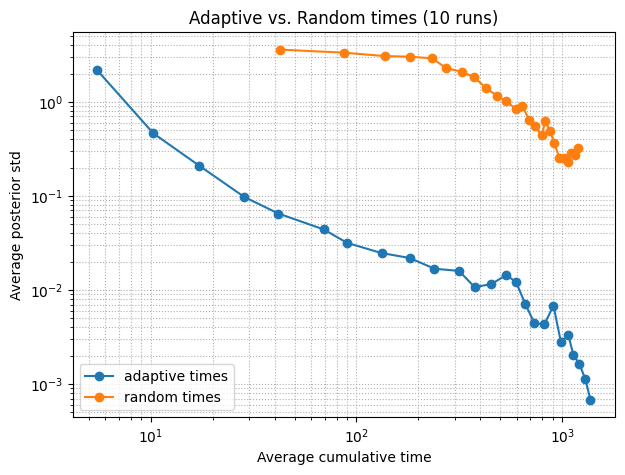

In [ ]:
domain = (0, 10)
w_true = 2.3
tmax = 100
nsteps = 25
nruns = 10
npoints = 500

r = run_both(w_true, domain, tmax, nsteps, nruns, npoints)

plot_comparison(*r)

## 4.4 Other strategies

The problem statement here is rather simple: have a function that we want to optimize at each iteration (`expected_utility`) by making a good choice of measurement time.

The optimization strategy chooses an arbitrary upper bound for our search range ($[0, \text{tmax}]$), picks an arbitrary number of candidates from this interval, and chooses the best one. This is very simple, somewhat _ad hoc_, and not necessarily optimal

## 4.5 Advanced challenge: experimental design


**Implement one or more different strategies of your choice, and assess their performance by plotting them along with the ones we considered before (adaptive and random). The goal is to beat both.** You can still use the `expected_utility` method, but not the `optimize_time` one.

This is an optional advanced assignment. If interested, please **submit a report with your solution** by **Monday, May 11th**.

The report should be self-contained and take the form of a Jupyter notebook with a brief problem statement, functional code, and explanations of your approach. You can also include your failed attempts at solutions e.g. to discuss why they failed.

**Feel free to explore¹**, test out things that spike your curiosity, see how they work out, and discuss them! The format is purposefully very open.

Notes:
- Please join the dedicated Discord server for advanced assignments.
- The previous tutorials are helpful starting points, as well as the resources shared on Discord.
- Please don't use LLM generated code, or code you haven't written yourself. If you don't understand something enough to explain it, don't include it.  
- If you have any questions or comments or topics you'd like to discuss, feel free to reach out! I'm happy to take questions, both during our meetings or asynchronously on Discord.
- The report can also mention, if relevant, your failed attempts at solutions; for instance, to discuss why they failed. You can also include limitations, further directions you would like to explore, etc.
- Make sure the notebook runs correctly before sending, by doing `disconnect and delete runtime` followed by `run all` on Google Colab before downloading the file for submission. Please test this even if you run the code locally.
- You can send it either as a Google Colab link or as a .ipynb file. In the former case, please don't forget to turn on link sharing on Colab (toggle the option `everyone with the link can see the file`).


_____

¹Examples of strategies you could attempt: more sophisticated optimization methods, machine learning, heuristics, dynamic search ranges, combinations of adaptive and non-adaptive measurement choices, etc.

For inspiration, here are some papers doing similar things (although more complex than is necessary for this exercise):

- [Experimental Phase Estimation Enhanced By Machine Learning](https://arxiv.org/pdf/1712.07570)
- [Neural-Network Heuristics for Adaptive Bayesian Quantum Estimation](https://arxiv.org/pdf/2003.02183)
- [Robust Online Hamiltonian Learning](https://arxiv.org/pdf/1207.1655)
- [Bayesian Quantum Amplitude Estimation](https://arxiv.org/pdf/2412.04394)

If any of these papers paper on  catches your eye (or any other related to the topic "Bayes for Quantum"), let me know! I can prepare a "journal club" type meeting.